# Retail Sales & Inventory Performance Analytics

This notebook uses only `sales_data.csv` to prepare a consistent cleaned export and describe sales, revenue, inventory, demand, products, categories, stores, regions, promotions, discounts, and seasonality. Promotion and discount comparisons are descriptive and do not establish causation.


## 1. Load and inspect the data

**What:** Load the original CSV and review its shape, sample rows, data types, and descriptive statistics.

**Why:** Confirm the dataset's structure before cleaning or calculating metrics.

**Result to review:** Check the row and column counts, field types, and value ranges.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('sales_data.csv')
print('Shape:', df.shape)
display(df.head())
df.info()
display(df.describe(include='all').T)

Shape: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,76000,760,2022-01-01,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store ID,76000,5,S001,15200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,76000,20,P0001,3800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,76000,5,Groceries,30400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,76000,4,North,30400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inventory Level,76000.0,NaN,NaN,NaN,301.062842,226.510161,0.0,136.0,227.0,408.0,2267.0
Units Sold,76000.0,NaN,NaN,NaN,88.827316,43.994525,0.0,58.0,84.0,114.0,426.0
Units Ordered,76000.0,NaN,NaN,NaN,89.090645,162.404627,0.0,0.0,0.0,121.0,1616.0
Price,76000.0,NaN,NaN,NaN,67.726028,39.377899,4.74,31.9975,64.5,95.83,228.03
Discount,76000.0,NaN,NaN,NaN,9.087039,7.475781,0.0,5.0,10.0,10.0,25.0


**Interview check:** Why inspect `shape` and `info()` before analysis? Which fields identify time, products, stores, and measures?


## 2. Check data quality and clean

**What:** Check missing values and duplicates, parse dates, convert numeric fields, remove rows missing required fields, and set whole-number types.

**Why:** Make the fields reliable for grouping and arithmetic while keeping invalid required values out of the analysis.

**Result to review:** Compare the before and after row counts, missing-value totals, duplicate counts, and date range. No values are imputed.


In [3]:
# Check missing values and exact duplicate rows before cleaning.
print('Missing values by column:')
display(df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())

# Remove exact duplicate rows and parse the date.
df = df.drop_duplicates().copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Convert numeric fields explicitly in case the source is read with mixed types.
numeric_columns = [
    'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
    'Promotion', 'Demand'
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Drop rows missing fields needed for the analysis. The source currently has no missing values.
required_columns = ['Date'] + numeric_columns + [
    'Store ID', 'Product ID', 'Category', 'Region', 'Seasonality'
]
df = df.dropna(subset=required_columns).copy()

# Use integer types for whole-number measures and flags.
integer_columns = [
    'Inventory Level', 'Units Sold', 'Units Ordered', 'Discount',
    'Promotion', 'Demand'
]
df[integer_columns] = df[integer_columns].astype('int64')
print('Cleaned shape:', df.shape)
print('Missing values after cleaning:', int(df.isna().sum().sum()))
print('Duplicate rows after cleaning:', int(df.duplicated().sum()))
print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())

Missing values by column:


Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

Duplicate rows: 0
Cleaned shape: (76000, 16)
Missing values after cleaning: 0
Duplicate rows after cleaning: 0
Date range: 2022-01-01 to 2024-01-30


**Interview check:** Why remove exact duplicates? Why convert `Date` and numeric fields? What does the required-field null handling do?


## 3. Add useful metrics

**What:** Add Revenue, Month, Year, Revenue per Unit, Inventory Gap, and Demand-to-Inventory Ratio from existing columns.

**Why:** These measures support revenue, time, sales-versus-inventory, and demand-versus-inventory analysis.

**Result to review:** Inspect the sample rows and summary statistics. The two ratios are undefined when their denominator is zero.


In [4]:
df['Revenue'] = df['Units Sold'] * df['Price']
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Year'] = df['Date'].dt.year
df['Revenue per Unit'] = df['Revenue'] / df['Units Sold'].replace(0, np.nan)
df['Inventory Gap'] = df['Inventory Level'] - df['Units Sold']
df['Demand-to-Inventory Ratio'] = df['Demand'] / df['Inventory Level'].replace(0, np.nan)
display(df.head())
display(df[['Revenue', 'Revenue per Unit', 'Inventory Gap', 'Demand-to-Inventory Ratio']].describe())

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Revenue,Month,Year,Revenue per Unit,Inventory Gap,Demand-to-Inventory Ratio
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,7417.44,2022-01,2022,72.72,93,0.589744
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,9378.72,2022-01,2022,80.16,0,1.957265
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,7175.16,2022-01,2022,62.94,133,0.635628
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,3943.35,2022-01,2022,87.63,94,0.374101
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,3536.65,2022-01,2022,54.41,87,0.388158


,Revenue,Revenue per Unit,Inventory Gap,Demand-to-Inventory Ratio
count,76000.000000,75594.000000,76000.000000,75594.000000
mean,5990.790717,67.734406,212.235526,0.604043
std,4756.214481,39.383424,220.378965,1.744227
min,0.000000,4.740000,0.000000,0.003150
25%,2426.595000,32.000000,49.000000,0.219687
50%,4789.285000,64.500000,140.000000,0.397077
75%,8349.327500,95.820000,315.000000,0.717391
max,69859.740000,228.030000,2195.000000,161.000000


**Interview check:** Why define revenue as units sold multiplied by price? How should a negative Inventory Gap be read? Why are ratios blank when the denominator is zero?


## 4. Exploratory analysis

**What:** Summarize units sold, revenue, demand, inventory, and averages across months, categories, products, regions, and stores.

**Why:** Compare performance at the business levels represented in the source.

**Result to review:** Read each grouped table and identify which measures are being compared; the code does not assume one product ID maps to only one category.


In [5]:
monthly = df.groupby('Month', as_index=False).agg(
    Units_Sold=('Units Sold', 'sum'), Revenue=('Revenue', 'sum'), Demand=('Demand', 'sum')
).sort_values('Month')
display(monthly.head())
display(df.groupby('Category').agg(
    Units_Sold=('Units Sold', 'sum'), Revenue=('Revenue', 'sum'),
    Avg_Inventory=('Inventory Level', 'mean'), Avg_Demand=('Demand', 'mean')
).sort_values('Revenue', ascending=False))
display(df.groupby('Region').agg(
    Units_Sold=('Units Sold', 'sum'), Revenue=('Revenue', 'sum')
).sort_values('Revenue', ascending=False))
display(df.groupby('Store ID').agg(
    Units_Sold=('Units Sold', 'sum'), Revenue=('Revenue', 'sum')
).sort_values('Revenue', ascending=False))
display(df.groupby(['Product ID', 'Category']).agg(
    Units_Sold=('Units Sold', 'sum'), Revenue=('Revenue', 'sum'),
    Avg_Inventory=('Inventory Level', 'mean'), Avg_Demand=('Demand', 'mean')
).sort_values('Revenue', ascending=False).head(10))

,Month,Units_Sold,Revenue,Demand
0,2022-01,283495,19453161.04,341544
1,2022-02,271108,18901066.87,319883
2,2022-03,303752,20417022.87,353173
3,2022-04,260812,17436597.55,305076
4,2022-05,205949,12895565.05,239112


,Units_Sold,Revenue,Avg_Inventory,Avg_Demand
Category,,,,
Groceries,3127335,1.688645e+08,360.314770,120.976447
Furniture,880654,1.112836e+08,250.074854,73.581140
Clothing,1150873,8.520061e+07,282.103536,112.619737
Electronics,757335,6.603987e+07,289.260417,97.482018
Toys,834679,2.391155e+07,229.111748,92.606955


,Units_Sold,Revenue
Region,,
North,2680946,1.700080e+08
East,1375613,9.852631e+07
West,1308191,9.446692e+07
South,1386126,9.229884e+07


,Units_Sold,Revenue
Store ID,,
S003,1375613,98526308.33
S004,1308191,94466923.20
S002,1386126,92298840.07
S001,1318134,89854451.03
S005,1362812,80153571.87


,,Units_Sold,Revenue,Avg_Inventory,Avg_Demand
Product ID,Category,,,,
P0020,Furniture,146598,17925202.36,268.931140,73.491228
P0010,Groceries,308032,16983572.73,300.486513,120.657566
P0009,Groceries,226674,16943785.15,270.225000,120.853509
P0014,Furniture,98449,15923624.85,228.878289,74.519079
P0013,Groceries,319111,15901559.54,446.142434,121.833224
P0009,Clothing,150097,15612954.68,275.421711,114.985526
P0014,Groceries,157049,13703192.03,401.057237,118.693421
P0018,Furniture,96135,13639948.53,247.959211,72.774342
P0011,Electronics,131332,13461761.62,323.642105,99.854605


### Inventory, promotion, discount, and seasonality comparisons

**What:** Compare product/category inventory, sales, and demand averages; calculate correlations; and group observations by promotion, discount, and season.

**Why:** These views help locate patterns and segments for follow-up analysis. Correlation and group differences are descriptive, not causal.

**Result to review:** Check the displayed group counts and averages and the two correlation values.


In [6]:
# Compare inventory, sales and demand at an aggregate level.
inventory_summary = df.groupby(['Product ID', 'Category']).agg(
    Avg_Inventory=('Inventory Level', 'mean'), Avg_Units_Sold=('Units Sold', 'mean'),
    Avg_Demand=('Demand', 'mean')
).sort_values('Avg_Demand', ascending=False)
display(inventory_summary.head(10))
print('Correlation of units sold with inventory:', round(df['Units Sold'].corr(df['Inventory Level']), 3))
print('Correlation of demand with inventory:', round(df['Demand'].corr(df['Inventory Level']), 3))

# Descriptive comparisons by promotion and discount.
display(df.groupby('Promotion').agg(
    Rows=('Units Sold', 'size'), Avg_Units_Sold=('Units Sold', 'mean'),
    Avg_Revenue=('Revenue', 'mean'), Total_Revenue=('Revenue', 'sum')
))
display(df.groupby('Discount').agg(
    Rows=('Units Sold', 'size'), Avg_Units_Sold=('Units Sold', 'mean'),
    Avg_Revenue=('Revenue', 'mean'), Total_Revenue=('Revenue', 'sum')
).sort_index())
display(df.groupby('Seasonality').agg(
    Total_Demand=('Demand', 'sum'), Total_Revenue=('Revenue', 'sum'), Avg_Units_Sold=('Units Sold', 'mean')
).sort_values('Total_Revenue', ascending=False))

,,Avg_Inventory,Avg_Units_Sold,Avg_Demand
Product ID,Category,,,
P0002,Clothing,152.034211,100.331579,124.643421
P0003,Clothing,570.423684,108.843421,123.335526
P0002,Groceries,351.909211,103.710526,122.928289
P0006,Groceries,426.615132,105.020395,122.220395
P0016,Groceries,379.193421,105.075000,122.177632
P0019,Groceries,147.575000,98.023684,122.051316
P0008,Groceries,143.541447,97.626974,122.023026
P0018,Groceries,168.986842,103.210526,121.905263
P0013,Groceries,446.142434,104.970724,121.833224


Correlation of units sold with inventory: 0.235
Correlation of demand with inventory: 0.127


,Rows,Avg_Units_Sold,Avg_Revenue,Total_Revenue
Promotion,,,,
0,51000,81.833314,5604.608655,2.858350e+08
1,25000,103.095080,6778.602124,1.694651e+08


,Rows,Avg_Units_Sold,Avg_Revenue,Total_Revenue
Discount,,,,
0,17126,81.574156,5912.382440,1.012555e+08
5,16918,81.694763,5563.087927,9.411632e+07
10,23298,87.657953,5886.932431,1.371538e+08
15,6245,102.878463,6971.354994,4.353611e+07
20,6191,103.774834,6628.057711,4.103431e+07
25,6222,103.587914,6140.170731,3.820414e+07


,Total_Demand,Total_Revenue,Avg_Units_Sold
Seasonality,,,
Winter,2171530,1.254143e+08,87.770524
Summer,2076539,1.207869e+08,95.757880
Autumn,1882298,1.082626e+08,88.462637
Spring,1797737,1.008363e+08,83.463587


**Interview check:** Why group product measures by both Product ID and Category? What can a correlation show, and what can it not prove? How are promotion comparisons interpreted?


## 5. Charts

**What:** Plot monthly units sold, monthly revenue, revenue by category, and row-level units sold against inventory.

**Why:** These views make time trends, category differences, and the spread between inventory and sales easier to inspect.

**Result to review:** Look for changes and differences in the plotted data. The charts do not establish causes.


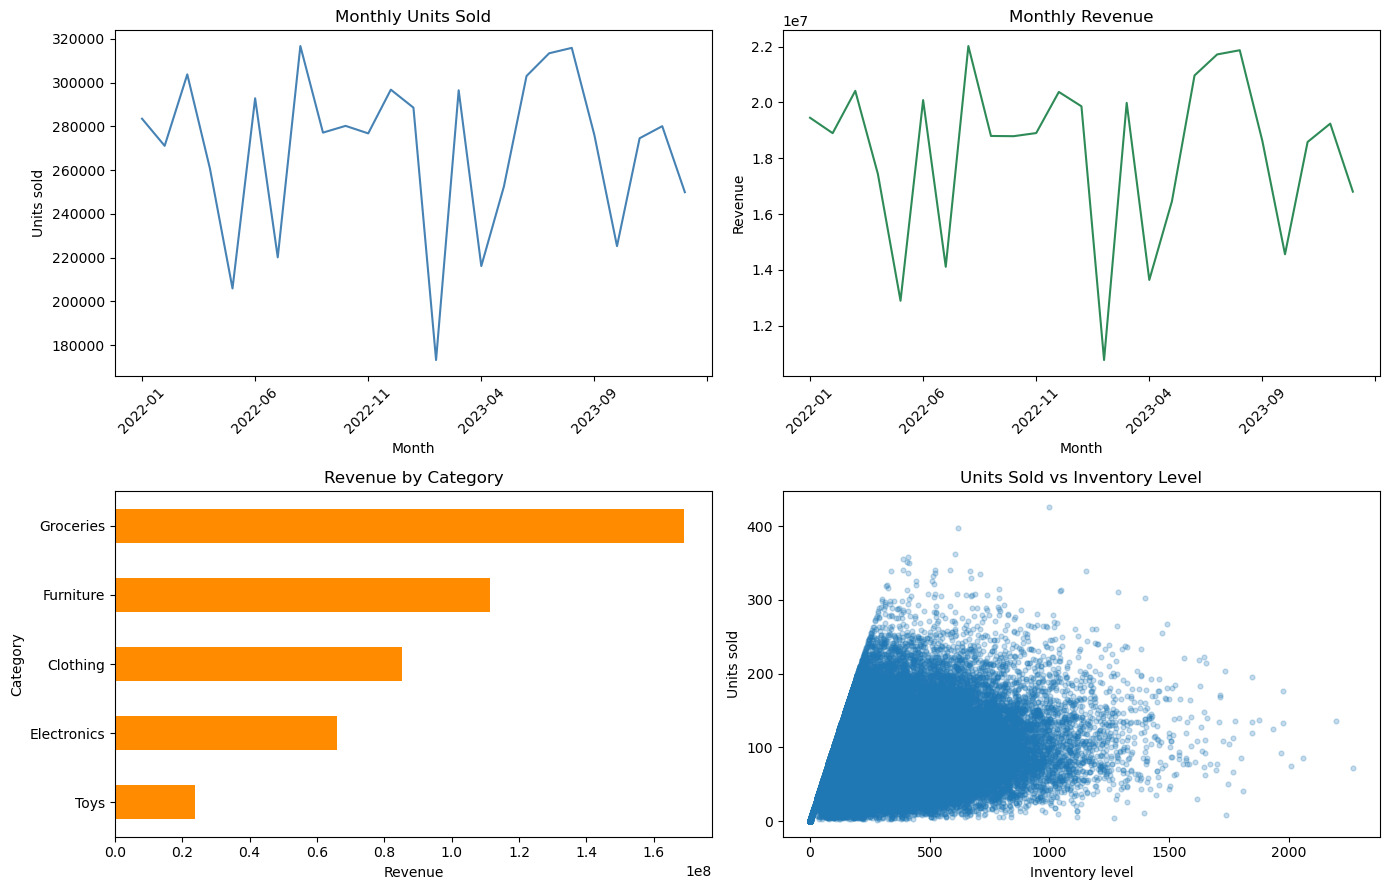

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
monthly.plot(x='Month', y='Units_Sold', ax=axes[0, 0], color='steelblue', legend=False)
axes[0, 0].set_title('Monthly Units Sold')
axes[0, 0].set_ylabel('Units sold')
axes[0, 0].tick_params(axis='x', rotation=45)
monthly.plot(x='Month', y='Revenue', ax=axes[0, 1], color='seagreen', legend=False)
axes[0, 1].set_title('Monthly Revenue')
axes[0, 1].set_ylabel('Revenue')
axes[0, 1].tick_params(axis='x', rotation=45)
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values()
category_revenue.plot(kind='barh', ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Revenue by Category')
axes[1, 0].set_xlabel('Revenue')
axes[1, 1].scatter(df['Inventory Level'], df['Units Sold'], alpha=0.25, s=12)
axes[1, 1].set_title('Units Sold vs Inventory Level')
axes[1, 1].set_xlabel('Inventory level')
axes[1, 1].set_ylabel('Units sold')
plt.tight_layout()
plt.show()

**Interview check:** Why use a line chart for monthly measures? Why is a scatter plot suitable for inventory and units sold?


## 6. Export the cleaned data

**What:** Save the cleaned rows and derived metrics as `cleaned_sales_data.csv` with the same 19 columns and order as the cleaned dataset, and `Date` written as ISO `YYYY-MM-DD`.

**Why:** Keep the Python output consistent with the declared export format and prepare a stable input for MySQL and Power BI.

**Result to review:** Confirm that the exported headers match the dataframe and that dates appear as `YYYY-MM-DD`. Import this CSV into MySQL as `retail_sales.cleaned_sales_data`; keep blank ratio values as `NULL`.


In [8]:
# Format only the export copy so Date stays datetime in the notebook analysis.
final_columns = [
    'Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level',
    'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Promotion', 'Seasonality',
    'Demand', 'Revenue', 'Month', 'Year', 'Revenue per Unit', 'Inventory Gap',
    'Demand-to-Inventory Ratio'
]
export_df = df[final_columns].copy()
export_df['Date'] = export_df['Date'].dt.strftime('%Y-%m-%d')
export_df.to_csv('cleaned_sales_data.csv', index=False)
print('Exported cleaned_sales_data.csv with', len(export_df), 'rows and', len(export_df.columns), 'columns.')

Exported cleaned_sales_data.csv with 76000 rows and 19 columns.


**Interview check:** Which file is the SQL input? How do you confirm that the exported column names and date format match the downstream analysis?


In [5]:

# FINAL PROJECT VERIFICATION — RETAIL SALES & INVENTORY


import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load final exported dataset
# ------------------------------------------------------------
try:
    verify_df = pd.read_csv("cleaned_sales_data.csv")
except FileNotFoundError:
    verify_df = df.copy()

# Convert Date safely
verify_df["Date"] = pd.to_datetime(verify_df["Date"], errors="coerce")

# ------------------------------------------------------------
# 2. Expected final schema
# ------------------------------------------------------------
expected_columns = [
    "Date",
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Seasonality",
    "Demand",
    "Revenue",
    "Month",
    "Year",
    "Revenue per Unit",
    "Inventory Gap",
    "Demand-to-Inventory Ratio"
]

# ------------------------------------------------------------
# 3. Basic checks
# ------------------------------------------------------------
shape_ok = verify_df.shape == (76000, 19)
columns_ok = list(verify_df.columns) == expected_columns
duplicates_ok = verify_df.duplicated().sum() == 0

dates_ok = (
    verify_df["Date"].notna().all()
    and verify_df["Date"].min() == pd.Timestamp("2022-01-01")
    and verify_df["Date"].max() == pd.Timestamp("2024-01-30")
    and verify_df["Date"].nunique() == 760
)

# ------------------------------------------------------------
# 4. Derived column checks
# ------------------------------------------------------------
month_ok = (
    verify_df["Month"].astype(str)
    == verify_df["Date"].dt.strftime("%Y-%m")
).all()

year_ok = (
    verify_df["Year"].astype(int)
    == verify_df["Date"].dt.year
).all()

revenue_ok = np.isclose(
    verify_df["Revenue"],
    verify_df["Units Sold"] * verify_df["Price"],
    atol=0.01
).all()

inventory_gap_ok = np.isclose(
    verify_df["Inventory Gap"],
    verify_df["Inventory Level"] - verify_df["Units Sold"],
    atol=0.01
).all()

# Revenue per Unit
rp_calc = np.where(
    verify_df["Units Sold"] != 0,
    verify_df["Revenue"] / verify_df["Units Sold"],
    np.nan
)

rp_ok = np.allclose(
    verify_df["Revenue per Unit"].fillna(np.nan),
    rp_calc,
    equal_nan=True,
    atol=1e-10
)

# Demand-to-Inventory Ratio
ratio_calc = np.where(
    verify_df["Inventory Level"] != 0,
    verify_df["Demand"] / verify_df["Inventory Level"],
    np.nan
)

ratio_ok = np.allclose(
    verify_df["Demand-to-Inventory Ratio"].fillna(np.nan),
    ratio_calc,
    equal_nan=True,
    atol=1e-10
)

# ------------------------------------------------------------
# 5. Expected KPI checks
# ------------------------------------------------------------
total_revenue = verify_df["Revenue"].sum()
total_units = verify_df["Units Sold"].sum()
total_demand = verify_df["Demand"].sum()
total_inventory = verify_df["Inventory Level"].sum()

restock_needed = (
    verify_df["Demand"] > verify_df["Inventory Level"]
).sum()

avg_revenue_per_unit = total_revenue / total_units

kpi_checks = {
    "Total Revenue": np.isclose(total_revenue, 455300094.50, atol=0.01),
    "Total Units Sold": total_units == 6750876,
    "Total Demand": total_demand == 7928104,
    "Total Inventory Level": total_inventory == 22880776,
    "Restock Needed": restock_needed == 10394,
    "Avg Revenue per Unit": np.isclose(
        avg_revenue_per_unit, 67.443113, atol=0.000001
    )
}

kpis_ok = all(kpi_checks.values())

# ------------------------------------------------------------
# 6. Dimension / grain checks
# ------------------------------------------------------------
dimensions_ok = (
    verify_df["Store ID"].nunique() == 5
    and verify_df["Product ID"].nunique() == 20
    and verify_df["Category"].nunique() == 5
    and verify_df["Region"].nunique() == 4
    and verify_df["Seasonality"].nunique() == 4
)

grain_ok = (
    verify_df.groupby(["Date", "Store ID", "Product ID"])
    .size()
    .max() == 1
)

zero_units = (verify_df["Units Sold"] == 0).sum()
zero_inventory = (verify_df["Inventory Level"] == 0).sum()

zero_denominator_ok = (
    zero_units == 406
    and zero_inventory == 406
)

# ------------------------------------------------------------
# 7. Print verification report
# ------------------------------------------------------------
print("=" * 70)
print("        RETAIL SALES & INVENTORY — FINAL VERIFICATION")
print("=" * 70)


print("\n--- VERIFIED KPIs ---")
print(f"Total Revenue              : ${total_revenue:,.2f}")
print(f"Total Units Sold           : {total_units:,}")
print(f"Total Demand               : {total_demand:,}")
print(f"Total Inventory Level      : {total_inventory:,}")
print(f"Restock Needed             : {restock_needed:,}")
print(f"Avg Revenue per Unit       : ${avg_revenue_per_unit:.2f}")

print("\n--- DATA QUALITY CHECKS ---")
checks = {
    "Shape = 76,000 × 19": shape_ok,
    "Column order correct": columns_ok,
    "No duplicate rows": duplicates_ok,
    "Dates valid": dates_ok,
    "Month matches Date": month_ok,
    "Year matches Date": year_ok,
    "Revenue formula correct": revenue_ok,
    "Inventory Gap formula correct": inventory_gap_ok,
    "Revenue per Unit formula correct": rp_ok,
    "Demand-to-Inventory Ratio formula correct": ratio_ok,
    "Expected KPIs match": kpis_ok,
    "Dimension counts correct": dimensions_ok,
    "Row grain unique": grain_ok,
    "Zero denominator counts correct": zero_denominator_ok
}

for check_name, result in checks.items():
    print(f"{'PASS' if result else 'FAIL':<6} | {check_name}")

print("\n--- KPI CHECK DETAILS ---")
for name, result in kpi_checks.items():
    print(f"{'PASS' if result else 'FAIL':<6} | {name}")

# ------------------------------------------------------------
# 8. Final result
# ------------------------------------------------------------
all_checks_passed = all(checks.values())

print("\n" + "=" * 70)



        RETAIL SALES & INVENTORY — FINAL VERIFICATION

--- VERIFIED KPIs ---
Total Revenue              : $455,300,094.50
Total Units Sold           : 6,750,876
Total Demand               : 7,928,104
Total Inventory Level      : 22,880,776
Restock Needed             : 10,394
Avg Revenue per Unit       : $67.44

--- DATA QUALITY CHECKS ---
PASS   | Shape = 76,000 × 19
PASS   | Column order correct
PASS   | No duplicate rows
PASS   | Dates valid
PASS   | Month matches Date
PASS   | Year matches Date
PASS   | Revenue formula correct
PASS   | Inventory Gap formula correct
PASS   | Revenue per Unit formula correct
PASS   | Demand-to-Inventory Ratio formula correct
PASS   | Expected KPIs match
PASS   | Dimension counts correct
PASS   | Row grain unique
PASS   | Zero denominator counts correct

--- KPI CHECK DETAILS ---
PASS   | Total Revenue
PASS   | Total Units Sold
PASS   | Total Demand
PASS   | Total Inventory Level
PASS   | Restock Needed
PASS   | Avg Revenue per Unit

